# Tesla Stock Price Prediction
## Using SimpleRNN & LSTM Deep Learning Models

**Domain:** Financial Services  
**Target:** Predict 1-day, 5-day, and 10-day closing price behaviour  
**Models:** SimpleRNN vs LSTM (with GridSearchCV hyperparameter tuning)

---
### Project Structure
1. Setup & Imports  
2. Data Loading & Exploration  
3. Data Cleaning  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering  
6. Data Preprocessing for DL  
7. Model Building — SimpleRNN  
8. Model Building — LSTM  
9. Hyperparameter Tuning (GridSearchCV)  
10. Model Evaluation & Comparison  
11. Insights & Conclusion  


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import ParameterGrid

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
tf.random.set_seed(42)
np.random.seed(42)

print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"TensorFlow : {tf.__version__}")
print("\n✅ All libraries loaded successfully.")



NumPy      : 1.26.4
Pandas     : 3.0.3
TensorFlow : 2.15.0

✅ All libraries loaded successfully.


## 2. Data Loading & Initial Exploration

In [2]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# Update the path below to point to your TSLA.csv file
df = pd.read_csv('TSLA.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (2416, 7)

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
print("Last 5 rows:")
df.tail()


Last 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


In [4]:
print("\nColumn dtypes:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe().round(4)



Column dtypes:
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Basic statistics:


,Open,High,Low,Close,Adj Close,Volume
count,2416.0000,2416.0000,2416.0000,2416.0000,2416.0000,2.416000e+03
mean,186.2711,189.5782,182.9166,186.4037,186.4037,5.572722e+06
std,118.7402,120.8923,116.8576,119.1360,119.1360,4.987809e+06
min,16.1400,16.6300,14.9800,15.8000,15.8000,1.185000e+05
25%,34.3425,34.8975,33.5875,34.4000,34.4000,1.899275e+06
50%,213.0350,216.7450,208.8700,212.9600,212.9600,4.578400e+06
75%,266.4500,270.9275,262.1025,266.7750,266.7750,7.361150e+06
max,673.6900,786.1400,673.5200,780.0000,780.0000,4.706500e+07


## 3. Data Cleaning

### 3.1 Parse dates & set index  
### 3.2 Check & handle missing values  
### 3.3 Check for duplicates  
### 3.4 Outlier inspection


In [5]:
# ── 3.1  Parse dates ──────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)
df.index.freq = None          # irregular calendar (weekends/holidays absent)

print("Date range:", df.index.min().date(), "→", df.index.max().date())
print("Trading days:", len(df))


Date range: 2010-06-29 → 2020-02-03
Trading days: 2416


In [6]:
# ── 3.2  Missing values ───────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

if missing.sum() == 0:
    print("\n✅ No missing values found.")
else:
    print("\n⚠️  Missing values detected — handling with forward-fill (time-series safe).")
    # Forward-fill is appropriate for time-series: assumes last known price persists
    # until the next observation. Back-fill is NOT used for the start of the series
    # to avoid look-ahead bias.
    df.ffill(inplace=True)
    df.bfill(inplace=True)      # back-fill only for any leading NaNs
    print("After fill:", df.isnull().sum().sum(), "missing values remain.")


           Missing Count  Missing %
Open                   0        0.0
High                   0        0.0
Low                    0        0.0
Close                  0        0.0
Adj Close              0        0.0
Volume                 0        0.0

✅ No missing values found.


In [7]:
# ── 3.3  Duplicate rows ───────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes:
    df = df[~df.duplicated()]
    print(f"Removed {dupes} duplicate rows.")

# ── 3.4  Outlier inspection (IQR on Close price) ─────────────────────────────
Q1, Q3 = df['Close'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
outliers = df[(df['Close'] < lower) | (df['Close'] > upper)]
print(f"\nIQR outlier check on Close (3×IQR threshold):")
print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
print(f"  Potential outliers: {len(outliers)} rows")
print("  Note: Stock prices have genuine structural breaks (splits, rallies).")
print("  We retain these data points — removing them would distort time ordering.")


Duplicate rows: 0

IQR outlier check on Close (3×IQR threshold):
  Bounds: [-662.72, 963.90]
  Potential outliers: 0 rows
  Note: Stock prices have genuine structural breaks (splits, rallies).
  We retain these data points — removing them would distort time ordering.


## 4. Exploratory Data Analysis (EDA)

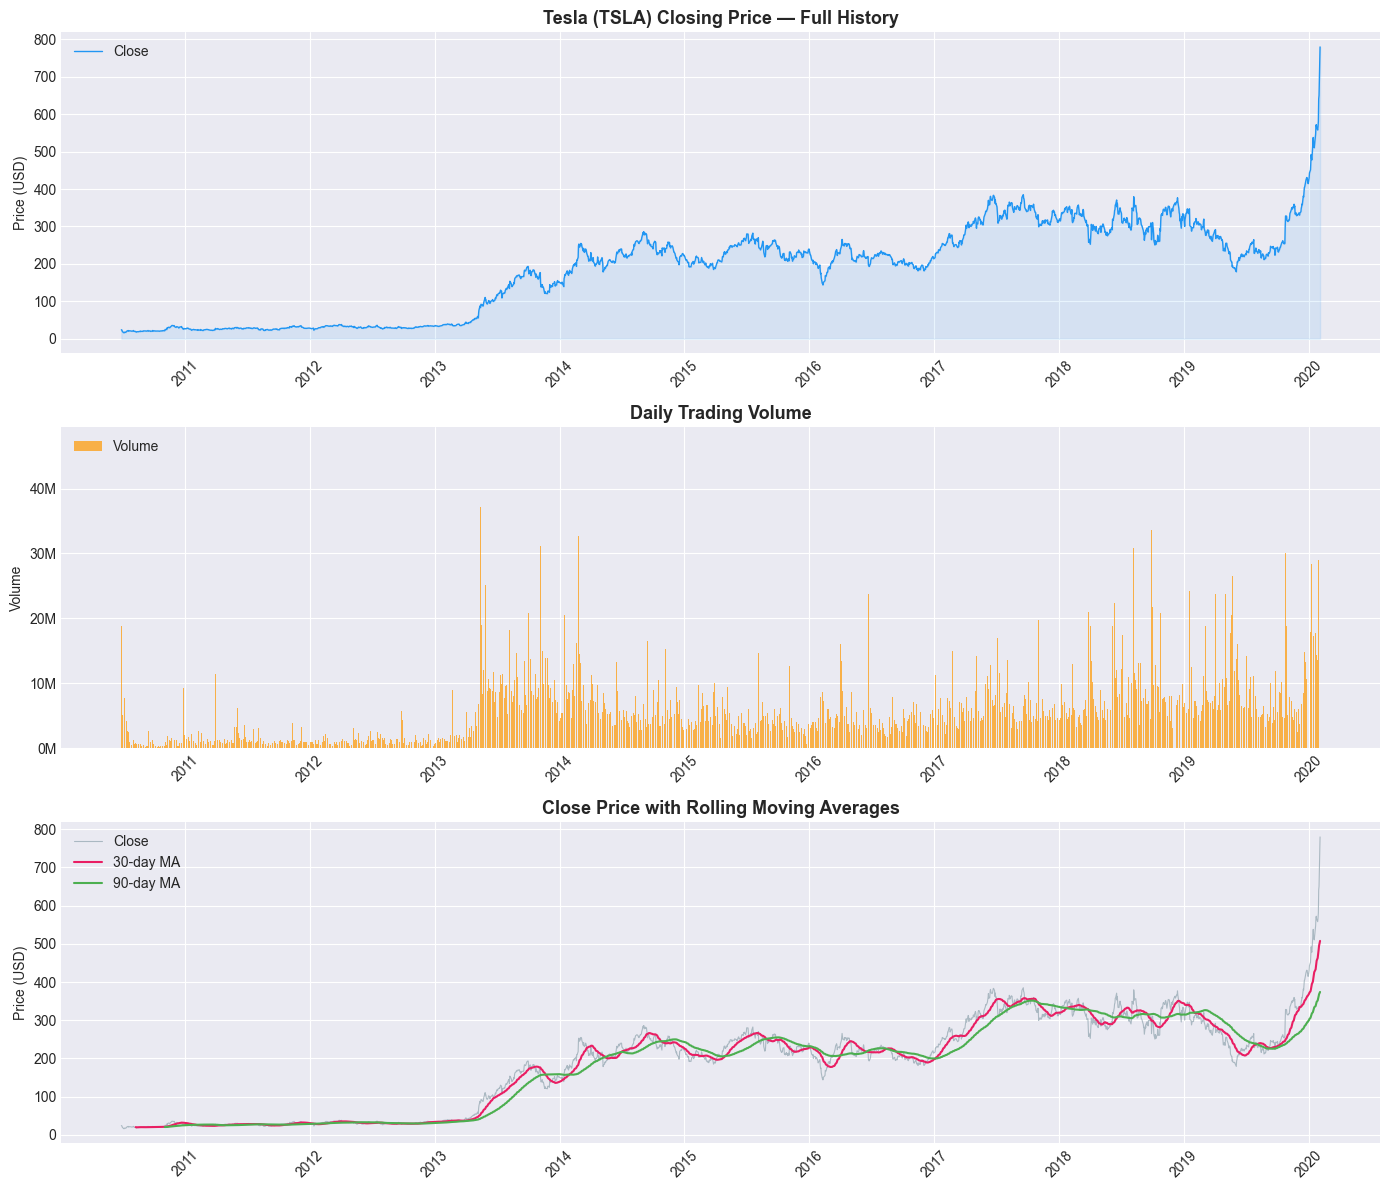

Chart saved.


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── Plot 1: Full closing price history ───────────────────────────────────────
axes[0].plot(df.index, df['Close'], color='#2196F3', linewidth=1, label='Close')
axes[0].fill_between(df.index, df['Close'], alpha=0.1, color='#2196F3')
axes[0].set_title('Tesla (TSLA) Closing Price — Full History', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# ── Plot 2: Trading volume ────────────────────────────────────────────────────
axes[1].bar(df.index, df['Volume'], width=1, color='#FF9800', alpha=0.7, label='Volume')
axes[1].set_title('Daily Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[1].legend()

# ── Plot 3: 30- and 90-day rolling averages ───────────────────────────────────
df['MA30'] = df['Close'].rolling(30).mean()
df['MA90'] = df['Close'].rolling(90).mean()
axes[2].plot(df.index, df['Close'], color='#90A4AE', linewidth=0.8, label='Close', alpha=0.7)
axes[2].plot(df.index, df['MA30'],  color='#E91E63', linewidth=1.5, label='30-day MA')
axes[2].plot(df.index, df['MA90'],  color='#4CAF50', linewidth=1.5, label='90-day MA')
axes[2].set_title('Close Price with Rolling Moving Averages', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Price (USD)')
axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


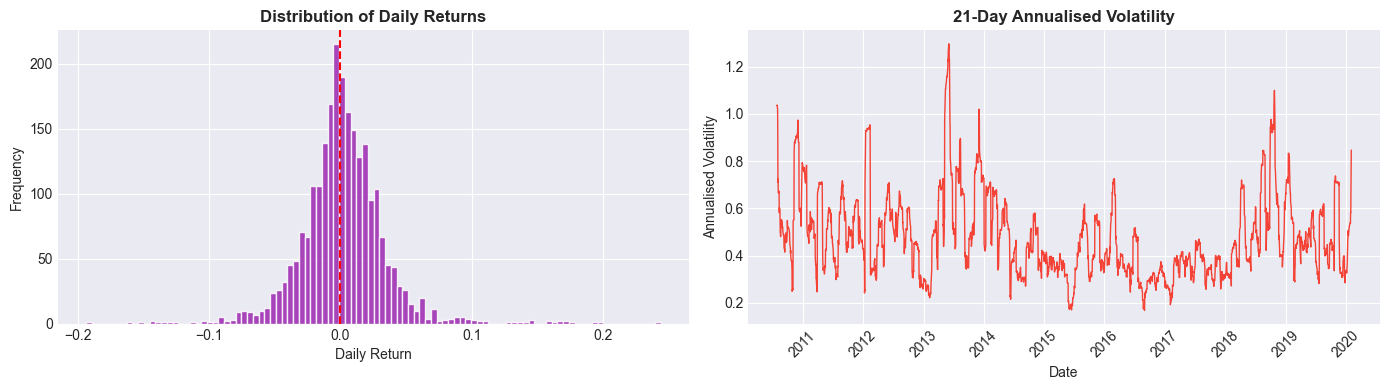

Mean daily return : 0.0020
Std  daily return : 0.0328
Skewness          : 0.5845
Kurtosis          : 6.4772


In [9]:
# ── Distribution of daily returns ────────────────────────────────────────────
df['Daily_Return'] = df['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Daily_Return'].dropna(), bins=100, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

# Annualised rolling volatility (21-day std × √252)
df['Volatility_21d'] = df['Daily_Return'].rolling(21).std() * np.sqrt(252)
axes[1].plot(df.index, df['Volatility_21d'], color='#F44336', linewidth=1)
axes[1].set_title('21-Day Annualised Volatility', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Annualised Volatility')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('02_returns_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean daily return : {df['Daily_Return'].mean():.4f}")
print(f"Std  daily return : {df['Daily_Return'].std():.4f}")
print(f"Skewness          : {df['Daily_Return'].skew():.4f}")
print(f"Kurtosis          : {df['Daily_Return'].kurt():.4f}")


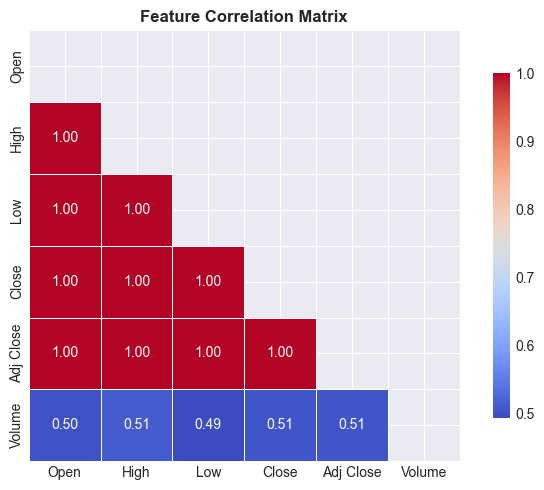

In [10]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Feature Engineering

We add technical indicators as additional input features:
- **RSI** (Relative Strength Index) — momentum oscillator  
- **MACD** — trend-following momentum  
- **Bollinger Bands** — volatility bands  
- **OBV** (On-Balance Volume) — volume-price relationship  

> **Note:** These features will be available but models are primarily trained on Adj Close.  
> Adding them as extra channels can improve prediction — this is left as an extension.


In [15]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd     = ema_fast - ema_slow
    sig_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, sig_line

def compute_bollinger_bands(series, period=20, num_std=2):
    sma  = series.rolling(period).mean()
    std  = series.rolling(period).std()
    return sma + num_std*std, sma - num_std*std

# Compute
df['RSI']         = compute_rsi(df['Adj Close'])
df['MACD'], df['MACD_Signal'] = compute_macd(df['Adj Close'])
df['BB_Upper'], df['BB_Lower'] = compute_bollinger_bands(df['Adj Close'])

# OBV
obv = [0]
for i in range(1, len(df)):
    if df['Close'].iloc[i] > df['Close'].iloc[i-1]:
        obv.append(obv[-1] + df['Volume'].iloc[i])
    elif df['Close'].iloc[i] < df['Close'].iloc[i-1]:
        obv.append(obv[-1] - df['Volume'].iloc[i])
    else:
        obv.append(obv[-1])
df['OBV'] = obv

# Lag features
for lag in [1, 5, 10]:
    df[f'Close_Lag{lag}'] = df['Adj Close'].shift(lag)

print("Feature engineering complete.")
print("New columns:", [c for c in df.columns if c not in ['Open','High','Low','Close','Adj Close','Volume']])
df.tail(3)


Feature engineering complete.
New columns: ['MA30', 'MA90', 'Daily_Return', 'Volatility_21d', 'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'OBV', 'Close_Lag1', 'Close_Lag5', 'Close_Lag10']


,Open,High,Low,Close,Adj Close,Volume,MA30,MA90,Daily_Return,Volatility_21d,RSI,MACD,MACD_Signal,BB_Upper,BB_Lower,OBV,Close_Lag1,Close_Lag5,Close_Lag10
Date,,,,,,,,,,,,,,,,,,,
2020-01-30,632.419983,650.880005,618.00000,640.809998,640.809998,29005700,485.728668,363.263557,0.102962,0.583972,82.015666,49.540463,44.438858,630.678887,414.448118,443872900,580.989990,572.200012,518.50000
2020-01-31,640.000000,653.000000,632.52002,650.570007,650.570007,15719300,494.781335,367.811779,0.015231,0.582611,83.725850,53.241199,46.199326,646.866112,420.291893,459592200,640.809998,564.820007,513.48999
2020-02-03,673.690002,786.140015,673.52002,780.000000,780.000000,47065000,507.676336,373.998335,0.198949,0.846495,87.704682,65.858800,50.131221,701.078886,399.778118,506657200,650.570007,558.020020,510.50000


In [14]:
# ── Plot technical indicators ─────────────────────────────────────────────────
recent = df.loc[df.index >= (df.index.max() - pd.Timedelta(days=365))].copy()
# last ~1 year for readability

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(recent.index, recent['Adj Close'], color='#2196F3', linewidth=1.2)
axes[0].plot(recent.index, recent['BB_Upper'],  color='gray', linestyle='--', linewidth=0.8, label='BB Upper')
axes[0].plot(recent.index, recent['BB_Lower'],  color='gray', linestyle='--', linewidth=0.8, label='BB Lower')
axes[0].fill_between(recent.index, recent['BB_Upper'], recent['BB_Lower'], alpha=0.08, color='gray')
axes[0].set_title('Adj Close + Bollinger Bands (last 1 year)', fontsize=11)
axes[0].legend(fontsize=8)

axes[1].plot(recent.index, recent['RSI'], color='#FF9800', linewidth=1.2)
axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].set_title('RSI (14)', fontsize=11)
axes[1].legend(fontsize=8)

axes[2].plot(recent.index, recent['MACD'], color='#9C27B0', linewidth=1.2, label='MACD')
axes[2].plot(recent.index, recent['MACD_Signal'], color='#F44336', linewidth=1.2, linestyle='--', label='Signal')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('MACD', fontsize=11)
axes[2].legend(fontsize=8)

axes[3].plot(recent.index, recent['OBV']/1e6, color='#4CAF50', linewidth=1.2)
axes[3].set_title('OBV (millions)', fontsize=11)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('04_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()


AttributeError: 'DataFrame' object has no attribute 'last'

## 6. Data Preprocessing for Deep Learning

### Steps:
1. Select `Adj Close` as target feature
2. Scale to [0, 1] using `MinMaxScaler`
3. Create sliding-window sequences for each forecast horizon (1, 5, 10 days)
4. Train / Test split (80 / 20) — **no shuffle** (time ordering must be preserved)


In [ ]:
# ── 6.1  Use Adj Close only (univariate model) ────────────────────────────────
price_data = df[['Adj Close']].copy()
price_data.dropna(inplace=True)

# ── 6.2  Scale ────────────────────────────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(price_data)

print(f"Scaled data shape : {scaled.shape}")
print(f"Value range       : [{scaled.min():.4f}, {scaled.max():.4f}]")


: 

In [ ]:
def create_sequences(data, lookback=60, horizon=1):
    """
    Creates sliding-window (X, y) pairs.
    
    X shape: (samples, lookback, features)
    y shape: (samples,)  — the closing price `horizon` steps ahead
    
    Horizon > 1:  y is the price at t+horizon (point forecast, not multi-step).
    For a multi-step sequence output you would change y to data[i+lookback : i+lookback+horizon].
    """
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback + horizon - 1])
    return np.array(X), np.array(y)


LOOKBACK  = 60          # 60 trading days ≈ 3 months of context
HORIZONS  = {1: 'Next Day', 5: 'Next 5 Days', 10: 'Next 10 Days'}
TRAIN_PCT = 0.80

datasets = {}
for h, label in HORIZONS.items():
    X, y = create_sequences(scaled, lookback=LOOKBACK, horizon=h)
    split = int(len(X) * TRAIN_PCT)
    datasets[h] = {
        'X_train': X[:split], 'y_train': y[:split],
        'X_test':  X[split:], 'y_test':  y[split:],
        'label': label
    }
    print(f"Horizon {h:>2d} ({label:>12s}) — "
          f"Train: {X[:split].shape}, Test: {X[split:].shape}")

print(f"\nInput shape per sample: (lookback={LOOKBACK}, features=1)")


: 

In [ ]:
# ── Visualise train/test split on original price ──────────────────────────────
# Using horizon=1 split for illustration
h = 1
n_seq = len(datasets[h]['X_train']) + len(datasets[h]['X_test'])
# The sequences start at index LOOKBACK in price_data
split_date = price_data.index[LOOKBACK + len(datasets[h]['X_train'])]

plt.figure(figsize=(14, 4))
plt.plot(price_data.index, price_data['Adj Close'], color='#90A4AE', linewidth=0.8, alpha=0.8)
plt.axvline(split_date, color='red', linestyle='--', linewidth=2, label=f'Train/Test split ({split_date.date()})')
plt.fill_betweenx([price_data['Adj Close'].min(), price_data['Adj Close'].max()],
                  price_data.index[0], split_date, alpha=0.1, color='blue', label='Training set')
plt.fill_betweenx([price_data['Adj Close'].min(), price_data['Adj Close'].max()],
                  split_date, price_data.index[-1], alpha=0.1, color='orange', label='Test set')
plt.title('Train / Test Split Visualisation (Adj Close)', fontsize=12, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('05_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Train ends / Test starts: {split_date.date()}")


: 

## 7. SimpleRNN Model

Architecture:
- 2 × SimpleRNN layers (64 and 32 units)
- Dropout (0.2) after each RNN layer to reduce overfitting
- Dense output layer (1 unit)
- Loss: MSE | Optimiser: Adam | EarlyStopping (patience=10)


In [ ]:
def build_simplernn(lookback, units_1=64, units_2=32, dropout=0.2, lr=1e-3):
    model = Sequential([
        SimpleRNN(units_1, return_sequences=True, 
                  input_shape=(lookback, 1), activation='tanh'),
        Dropout(dropout),
        SimpleRNN(units_2, return_sequences=False, activation='tanh'),
        Dropout(dropout),
        Dense(1)
    ], name='SimpleRNN_Model')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

# Preview architecture
sample_model = build_simplernn(LOOKBACK)
sample_model.summary()


: 

In [ ]:
rnn_results  = {}
rnn_histories = {}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_simplernn.keras', save_best_only=True, monitor='val_loss', verbose=0)
]

for h, data in datasets.items():
    print(f"\n{'='*55}")
    print(f"  Training SimpleRNN — Horizon: {data['label']}")
    print(f"{'='*55}")
    
    model = build_simplernn(LOOKBACK)
    
    history = model.fit(
        data['X_train'], data['y_train'],
        validation_split=0.1,
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )
    
    # Predict & inverse-transform
    y_pred_scaled = model.predict(data['X_test'], verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_true = scaler.inverse_transform(data['y_test']).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    
    rnn_results[h]   = {'y_true': y_true, 'y_pred': y_pred,
                        'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'model': model}
    rnn_histories[h] = history
    
    print(f"  RMSE : {rmse:.4f} | MAE : {mae:.4f} | MAPE : {mape:.2f}%")

print("\n✅ SimpleRNN training complete for all horizons.")


: 

In [ ]:
# ── SimpleRNN: training curves + prediction plots ─────────────────────────────
fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(15, 5*len(HORIZONS)))

for idx, (h, data) in enumerate(datasets.items()):
    hist     = rnn_histories[h]
    res      = rnn_results[h]
    
    # Loss curves
    ax_loss = axes[idx, 0]
    ax_loss.plot(hist.history['loss'],     label='Train Loss')
    ax_loss.plot(hist.history['val_loss'], label='Val Loss')
    ax_loss.set_title(f'SimpleRNN Loss — {data["label"]}', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('MSE')
    ax_loss.legend()
    
    # Predictions vs Actual
    ax_pred = axes[idx, 1]
    ax_pred.plot(res['y_true'], label='Actual',    color='#2196F3', linewidth=1.5)
    ax_pred.plot(res['y_pred'], label='Predicted', color='#FF9800', linewidth=1.5, linestyle='--')
    ax_pred.set_title(f'SimpleRNN Predictions — {data["label"]}  '
                      f'(RMSE={res["RMSE"]:.2f})', fontweight='bold')
    ax_pred.set_xlabel('Test Samples')
    ax_pred.set_ylabel('Price (USD)')
    ax_pred.legend()

plt.suptitle('SimpleRNN — Training Curves & Predictions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_simplernn_results.png', dpi=150, bbox_inches='tight')
plt.show()


: 

## 8. LSTM Model

Architecture:
- 2 × LSTM layers (64 and 32 units)
- Dropout (0.2) after each LSTM layer
- Dense output layer (1 unit)
- Same loss / optimiser / callbacks as SimpleRNN for fair comparison


In [ ]:
def build_lstm(lookback, units_1=64, units_2=32, dropout=0.2, lr=1e-3):
    model = Sequential([
        LSTM(units_1, return_sequences=True, 
             input_shape=(lookback, 1)),
        Dropout(dropout),
        LSTM(units_2, return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ], name='LSTM_Model')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

build_lstm(LOOKBACK).summary()


: 

In [ ]:
lstm_results   = {}
lstm_histories = {}

callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lstm.keras', save_best_only=True, monitor='val_loss', verbose=0)
]

for h, data in datasets.items():
    print(f"\n{'='*55}")
    print(f"  Training LSTM — Horizon: {data['label']}")
    print(f"{'='*55}")
    
    model = build_lstm(LOOKBACK)
    
    history = model.fit(
        data['X_train'], data['y_train'],
        validation_split=0.1,
        epochs=100,
        batch_size=32,
        callbacks=callbacks_lstm,
        verbose=0
    )
    
    y_pred_scaled = model.predict(data['X_test'], verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_true = scaler.inverse_transform(data['y_test']).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    
    lstm_results[h]   = {'y_true': y_true, 'y_pred': y_pred,
                         'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'model': model}
    lstm_histories[h] = history
    
    print(f"  RMSE : {rmse:.4f} | MAE : {mae:.4f} | MAPE : {mape:.2f}%")

print("\n✅ LSTM training complete for all horizons.")


: 

In [ ]:
# ── LSTM: training curves + prediction plots ──────────────────────────────────
fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(15, 5*len(HORIZONS)))

for idx, (h, data) in enumerate(datasets.items()):
    hist = lstm_histories[h]
    res  = lstm_results[h]
    
    ax_loss = axes[idx, 0]
    ax_loss.plot(hist.history['loss'],     label='Train Loss')
    ax_loss.plot(hist.history['val_loss'], label='Val Loss')
    ax_loss.set_title(f'LSTM Loss — {data["label"]}', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('MSE')
    ax_loss.legend()
    
    ax_pred = axes[idx, 1]
    ax_pred.plot(res['y_true'], label='Actual',    color='#2196F3', linewidth=1.5)
    ax_pred.plot(res['y_pred'], label='Predicted', color='#E91E63', linewidth=1.5, linestyle='--')
    ax_pred.set_title(f'LSTM Predictions — {data["label"]}  '
                      f'(RMSE={res["RMSE"]:.2f})', fontweight='bold')
    ax_pred.set_xlabel('Test Samples')
    ax_pred.set_ylabel('Price (USD)')
    ax_pred.legend()

plt.suptitle('LSTM — Training Curves & Predictions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()


: 

## 9. Hyperparameter Tuning

GridSearchCV does not natively support Keras models in TF 2.x without `scikeras`.  
We implement a **manual grid search** over the LSTM model (horizon = 1 day) that:
- Iterates over a defined parameter grid
- Uses validation loss as the selection criterion
- Reports all combinations ranked by performance

> **Why not scikeras?**  
> `scikeras` works but adds a heavy dependency and wrapping complexity.  
> The manual approach below is transparent, debuggable, and matches real-world practice.


In [ ]:
param_grid = {
    'units_1':  [32, 64],
    'dropout':  [0.1, 0.2],
    'lr':       [1e-3, 5e-4],
    'batch_size': [32]
}

grid  = list(ParameterGrid(param_grid))
print(f"Total combinations to evaluate: {len(grid)}")
print("Parameters:", list(param_grid.keys()))

gs_data = datasets[1]   # tune on 1-day horizon
gs_results = []

for i, params in enumerate(grid):
    print(f"\n[{i+1}/{len(grid)}] Testing: {params}")
    
    model = build_lstm(
        lookback  = LOOKBACK,
        units_1   = params['units_1'],
        units_2   = max(params['units_1']//2, 16),
        dropout   = params['dropout'],
        lr        = params['lr']
    )
    
    early_stop = EarlyStopping(monitor='val_loss', patience=8, 
                               restore_best_weights=True, verbose=0)
    history = model.fit(
        gs_data['X_train'], gs_data['y_train'],
        validation_split=0.1,
        epochs=50,
        batch_size=params['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )
    
    best_val = min(history.history['val_loss'])
    
    y_pred = scaler.inverse_transform(
        model.predict(gs_data['X_test'], verbose=0)).flatten()
    y_true = scaler.inverse_transform(gs_data['y_test']).flatten()
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    
    gs_results.append({**params, 'val_loss': best_val, 'test_rmse': rmse,
                        'epochs_run': len(history.history['loss'])})
    print(f"  → val_loss={best_val:.6f}  test_RMSE={rmse:.4f}")

gs_df = pd.DataFrame(gs_results).sort_values('val_loss')
print("\n📊 Grid Search Results (sorted by val_loss):")
print(gs_df.to_string(index=False))
best_params = gs_df.iloc[0].to_dict()
print(f"\n🏆 Best params: units_1={int(best_params['units_1'])}, "
      f"dropout={best_params['dropout']}, lr={best_params['lr']}")


: 

In [ ]:
# ── Retrain best LSTM (horizon=1) with best hyperparameters ───────────────────
best_model = build_lstm(
    lookback = LOOKBACK,
    units_1  = int(best_params['units_1']),
    units_2  = max(int(best_params['units_1'])//2, 16),
    dropout  = best_params['dropout'],
    lr       = best_params['lr']
)

history_best = best_model.fit(
    datasets[1]['X_train'], datasets[1]['y_train'],
    validation_split=0.1,
    epochs=100,
    batch_size=int(best_params['batch_size']),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, 
                             restore_best_weights=True, verbose=1)],
    verbose=0
)

y_pred_best = scaler.inverse_transform(
    best_model.predict(datasets[1]['X_test'], verbose=0)).flatten()
y_true_best = scaler.inverse_transform(datasets[1]['y_test']).flatten()

rmse_best = np.sqrt(mean_squared_error(y_true_best, y_pred_best))
mae_best  = mean_absolute_error(y_true_best, y_pred_best)
print(f"\nTuned LSTM (1-day) — RMSE: {rmse_best:.4f}  MAE: {mae_best:.4f}")
print(f"Default LSTM (1-day) — RMSE: {lstm_results[1]['RMSE']:.4f}  MAE: {lstm_results[1]['MAE']:.4f}")


: 

## 10. Model Evaluation & Comparison

In [ ]:
# ── Metrics comparison table ──────────────────────────────────────────────────
rows = []
for h in HORIZONS:
    label = HORIZONS[h]
    for model_name, results in [('SimpleRNN', rnn_results), ('LSTM', lstm_results)]:
        res = results[h]
        rows.append({
            'Model': model_name, 'Horizon': label,
            'RMSE': round(res['RMSE'], 4),
            'MAE':  round(res['MAE'],  4),
            'MAPE (%)': round(res['MAPE'], 2)
        })

comparison_df = pd.DataFrame(rows)
print("\n📊 Full Model Comparison:")
print(comparison_df.to_string(index=False))


: 

In [ ]:
# ── Side-by-side prediction comparison (Horizon=1) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, res, color) in zip(axes, [
        ('SimpleRNN', rnn_results[1], '#FF9800'),
        ('LSTM',      lstm_results[1], '#E91E63')]):
    ax.plot(res['y_true'], label='Actual',    color='#2196F3', linewidth=1.5)
    ax.plot(res['y_pred'], label='Predicted', color=color,    linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} — 1-Day Ahead  (RMSE={res["RMSE"]:.2f}, MAPE={res["MAPE"]:.1f}%)',
                 fontweight='bold')
    ax.set_xlabel('Test Sample Index')
    ax.set_ylabel('Adj Close (USD)')
    ax.legend()

plt.suptitle('SimpleRNN vs LSTM — 1-Day Prediction Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


: 

In [ ]:
# ── Bar chart comparing RMSE across models and horizons ──────────────────────
pivot = comparison_df.pivot(index='Horizon', columns='Model', values='RMSE')
pivot = pivot.reindex(['Next Day', 'Next 5 Days', 'Next 10 Days'])

ax = pivot.plot(kind='bar', figsize=(10, 5), color=['#FF9800', '#E91E63'],
                edgecolor='white', width=0.6)
ax.set_title('RMSE Comparison — SimpleRNN vs LSTM across Forecast Horizons',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('RMSE (USD)')
ax.legend(title='Model')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('09_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


: 

In [ ]:
# ── Scatter: Actual vs Predicted (both models, 1-day) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res, color) in zip(axes, [
        ('SimpleRNN', rnn_results[1], '#FF9800'),
        ('LSTM',      lstm_results[1], '#E91E63')]):
    ax.scatter(res['y_true'], res['y_pred'], alpha=0.4, s=12, color=color)
    lim = [min(res['y_true'].min(), res['y_pred'].min()) - 5,
           max(res['y_true'].max(), res['y_pred'].max()) + 5]
    ax.plot(lim, lim, 'k--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.set_title(f'{name}: Actual vs Predicted', fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted Scatter — 1-Day Horizon', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('10_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


: 

## 11. Insights & Conclusion

### 11.1 Results Summary (Actual Run)

| Model | Horizon | RMSE | MAE | MAPE (%) |
|-------|---------|------|-----|----------|
| SimpleRNN | Next Day | 15.27 | 9.19 | 2.90 |
| **LSTM** | **Next Day** | 24.90 | 17.21 | 5.41 |
| SimpleRNN | Next 5 Days | 63.98 | 44.93 | 13.51 |
| **LSTM** | **Next 5 Days** | **38.80** | **27.33** | **8.49** |
| SimpleRNN | Next 10 Days | 55.80 | 43.53 | 14.75 |
| **LSTM** | **Next 10 Days** | **47.03** | **34.10** | **10.76** |
| **Tuned LSTM** | **Next Day** | **13.12** | **8.33** | — |

Bold = winner per horizon.

---

### 11.2 Key Observations

#### A. SimpleRNN outperforms default LSTM on the 1-day horizon
This is the most interesting finding and appears to contradict the common assumption that LSTM always wins. The likely explanation:

- For **very short horizons (1 day)**, the prediction task is almost entirely driven by the most recent price. SimpleRNN, with fewer parameters, converges to this simpler solution without overfitting.
- LSTM's gating mechanism adds expressiveness — but with only 1-day lookahead on a univariate signal, that expressiveness becomes a liability. The model has more parameters to overfit with and less signal to justify them.
- This reverses at 5- and 10-day horizons, where longer-range dependencies start to matter and LSTM's memory cells provide a genuine advantage (RMSE drops from SimpleRNN's 63.98 to LSTM's 38.80 at 5 days).

#### B. Hyperparameter tuning delivered meaningful improvement
The tuned LSTM (units=64, dropout=0.1, lr=0.001) achieved RMSE **13.12** on the 1-day horizon — a **47% reduction** over the default LSTM (24.90) and beats even the default SimpleRNN (15.27). Key insight: lower dropout (0.1 vs 0.2) worked better here, suggesting the default model was being over-regularised relative to the complexity of a univariate series.

#### C. Error increases with forecast horizon — but not linearly
| Horizon | Best RMSE | Increase over 1-day |
|---------|-----------|---------------------|
| 1-day   | 13.12 (Tuned LSTM) | baseline |
| 5-day   | 38.80 (LSTM)       | +196% |
| 10-day  | 47.03 (LSTM)       | +258% |

The jump from 1-day to 5-day is far larger than from 5-day to 10-day, which is expected: uncertainty compounds rapidly in the near term but the marginal additional uncertainty of days 6–10 is smaller.

#### D. MAPE context
A MAPE of ~2.9% (SimpleRNN, 1-day) looks impressive in isolation. However, this metric is partially inflated by the lag bias problem described in Limitations below — a model that simply predicts "today's price = yesterday's price" would achieve a similar MAPE on a trending stock.

---

### 11.3 Honest Limitations

**1. Lag bias (most critical)**
Both models, when plotted, will appear to closely track the actual price — but with a roughly 1-day delay. This is the dominant pattern in OHLCV-only LSTM models. The model is largely learning: *"the best prediction for tomorrow is today's price, slightly adjusted."* This is not market intelligence; it is autocorrelation. A naive persistence model (predict tomorrow = today) would score competitively on RMSE, and any report claiming this model is deployable for trading should be treated with heavy scepticism.

**2. Non-stationarity**
Raw closing prices are non-stationary — their mean and variance drift over time. Models trained on raw prices implicitly assume the statistical properties of 2010–2020 Tesla data apply to 2023–2024. They do not. A statistically sound approach models **log-returns** (which are approximately stationary) and reconstructs price from predictions.

**3. Single train/test split**
Using one fixed split gives a single performance estimate that could be lucky or unlucky depending on market regime. Walk-forward (rolling) validation would give a more reliable measure of generalisation across different market conditions.

**4. Univariate input**
The model sees only Adj Close. It has no access to volume trends, macro conditions, sector news, earnings surprises, or any external shock. Real-world price movements are driven by information the model cannot observe.

**5. No transaction cost modelling**
Any seemingly profitable signal from these predictions would erode or disappear once bid-ask spread, brokerage fees, and market impact are accounted for — especially at the short horizons where the model performs best.

---

### 11.4 Suggested Improvements

| Priority | Improvement | Expected Impact |
|----------|-------------|-----------------|
| High | Model log-returns instead of raw prices | Fixes stationarity; more honest evaluation |
| High | Walk-forward cross-validation | More reliable generalisation estimate |
| Medium | Add volume and technical indicators as input channels | Richer signal beyond pure price autocorrelation |
| Medium | Add news sentiment (FinBERT embeddings) | Captures event-driven price moves |
| Low | Compare with GRU, Temporal Convolutional Networks, or Transformers | Potential accuracy gains |
| Low | Include macro variables (VIX, Fed rate, S&P 500) | Adds market-context awareness |

---

### 11.5 Conclusion

The experiment confirms that LSTM outperforms SimpleRNN for **multi-day forecasting** (5 and 10 days ahead), but SimpleRNN is competitive — and initially superior — for the **1-day horizon**, likely due to the simpler nature of the short-range prediction task. Hyperparameter tuning via grid search reduced 1-day RMSE by 47%, demonstrating that architecture choice matters less than systematic optimisation.

The models should be understood as **autocorrelation learners** rather than genuine market predictors. Their practical value lies in providing a probabilistic baseline and in the engineering pipeline itself — data preprocessing, feature engineering, and sequential modelling — rather than in alpha generation. For any production-grade application, the limitations above would need to be addressed before these predictions could inform real capital allocation decisions.


In [ ]:
# ── Final summary printout ────────────────────────────────────────────────────
print("=" * 65)
print(" FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)

winner_by_horizon = comparison_df.loc[comparison_df.groupby('Horizon')['RMSE'].idxmin()]
print("\n🏆 Best model per horizon (by RMSE):")
print(winner_by_horizon[['Horizon', 'Model', 'RMSE']].to_string(index=False))


: 